# 3. Posterior Analysis — Model 1 (Normal Likelihood)

## Model Specification

$$y_i \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist} \cdot \text{distance\_std}_i + \beta_{elev} \cdot \text{elevation\_std}_i$$

**Priors:**
- $\alpha \sim \text{Normal}(10, 5)$
- $\beta_{dist} \sim \text{Normal}(5, 3)$
- $\beta_{elev} \sim \text{Normal}(2, 2)$
- $\sigma \sim \text{Exponential}(0.2)$

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load processed data
df_full = pd.read_csv('utmb_processed.csv')
# Subsample for computational feasibility
# (36K obs × 8000 posterior draws = ~2.3 GB per generated quantity array → kernel crash)
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Data: {df.shape[0]:,} observations (subsampled from {df_full.shape[0]:,})")
print(f"Categories: {df['Race Category'].value_counts().to_dict()}")

Data: 5,000 observations (subsampled from 36,433)
Categories: {'50K': 2101, '20K': 1503, '100K': 1016, '100M': 380}


In [2]:
# Prepare Stan data
stan_data = {
    'N': len(df),
    'y': df['Mean Finish Time'].values.tolist(),
    'distance_std': df['distance_std'].values.tolist(),
    'elevation_std': df['elevation_std'].values.tolist()
}

# Compile and fit Model 1
model1 = CmdStanModel(stan_file='model1_normal.stan')
print("Model 1 (Normal) compiled.")

Model 1 (Normal) compiled.


In [3]:
# Fit Model 1
fit1 = model1.sample(
    data=stan_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    seed=42,
    show_progress=True
)
print("Sampling complete.")

09:17:33 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

09:17:39 - cmdstanpy - INFO - CmdStan done processing.



Sampling complete.


## 3.1 Sampling Diagnostics

We check:
- R-hat (should be < 1.01)
- ESS bulk and tail (should be > 400)
- Divergences (should be 0)
- Trace plots (chains should be well-mixed)

In [4]:
# Convert to ArviZ InferenceData
idata1 = az.from_cmdstanpy(
    fit1,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
    observed_data={'y': df['Mean Finish Time'].values}
)

# Print summary of key parameters
print("=" * 70)
print("MODEL 1 (Normal) — Posterior Summary")
print("=" * 70)
summary1 = az.summary(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'])
print(summary1.to_string())

MODEL 1 (Normal) — Posterior Summary
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha      10.659  0.034  10.598   10.724      0.001    0.001    3791.0    2533.0    1.0
beta_dist   6.225  0.053   6.126    6.326      0.001    0.001    2585.0    2578.0    1.0
beta_elev   2.589  0.051   2.490    2.681      0.001    0.001    2659.0    2444.0    1.0
sigma       2.443  0.024   2.398    2.489      0.000    0.000    3898.0    2554.0    1.0


In [5]:
# Check for sampling issues
print("\n=== MCMC Diagnostics ===")

# Divergences
divergences = fit1.diagnose()
print(f"\nDiagnostics output:")
print(divergences)


=== MCMC Diagnostics ===

Diagnostics output:
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
# R-hat and ESS check
rhat_vals = summary1['r_hat'].values
ess_bulk_vals = summary1['ess_bulk'].values
ess_tail_vals = summary1['ess_tail'].values

print("R-hat values:")
for param, rhat in zip(summary1.index, rhat_vals):
    status = '✓' if rhat < 1.01 else '✗ WARNING'
    print(f"  {param}: {rhat:.4f} {status}")

print(f"\nESS bulk (min): {ess_bulk_vals.min():.0f} {'✓' if ess_bulk_vals.min() > 400 else '✗ WARNING'}")
print(f"ESS tail (min): {ess_tail_vals.min():.0f} {'✓' if ess_tail_vals.min() > 400 else '✗ WARNING'}")

print(f"\nAll R-hat < 1.01: {all(rhat_vals < 1.01)}")
print(f"All ESS_bulk > 400: {all(ess_bulk_vals > 400)}")
print(f"All ESS_tail > 400: {all(ess_tail_vals > 400)}")

R-hat values:
  alpha: 1.0000 ✓
  beta_dist: 1.0000 ✓
  beta_elev: 1.0000 ✓
  sigma: 1.0000 ✓

ESS bulk (min): 2585 ✓
ESS tail (min): 2444 ✓

All R-hat < 1.01: True
All ESS_bulk > 400: True
All ESS_tail > 400: True


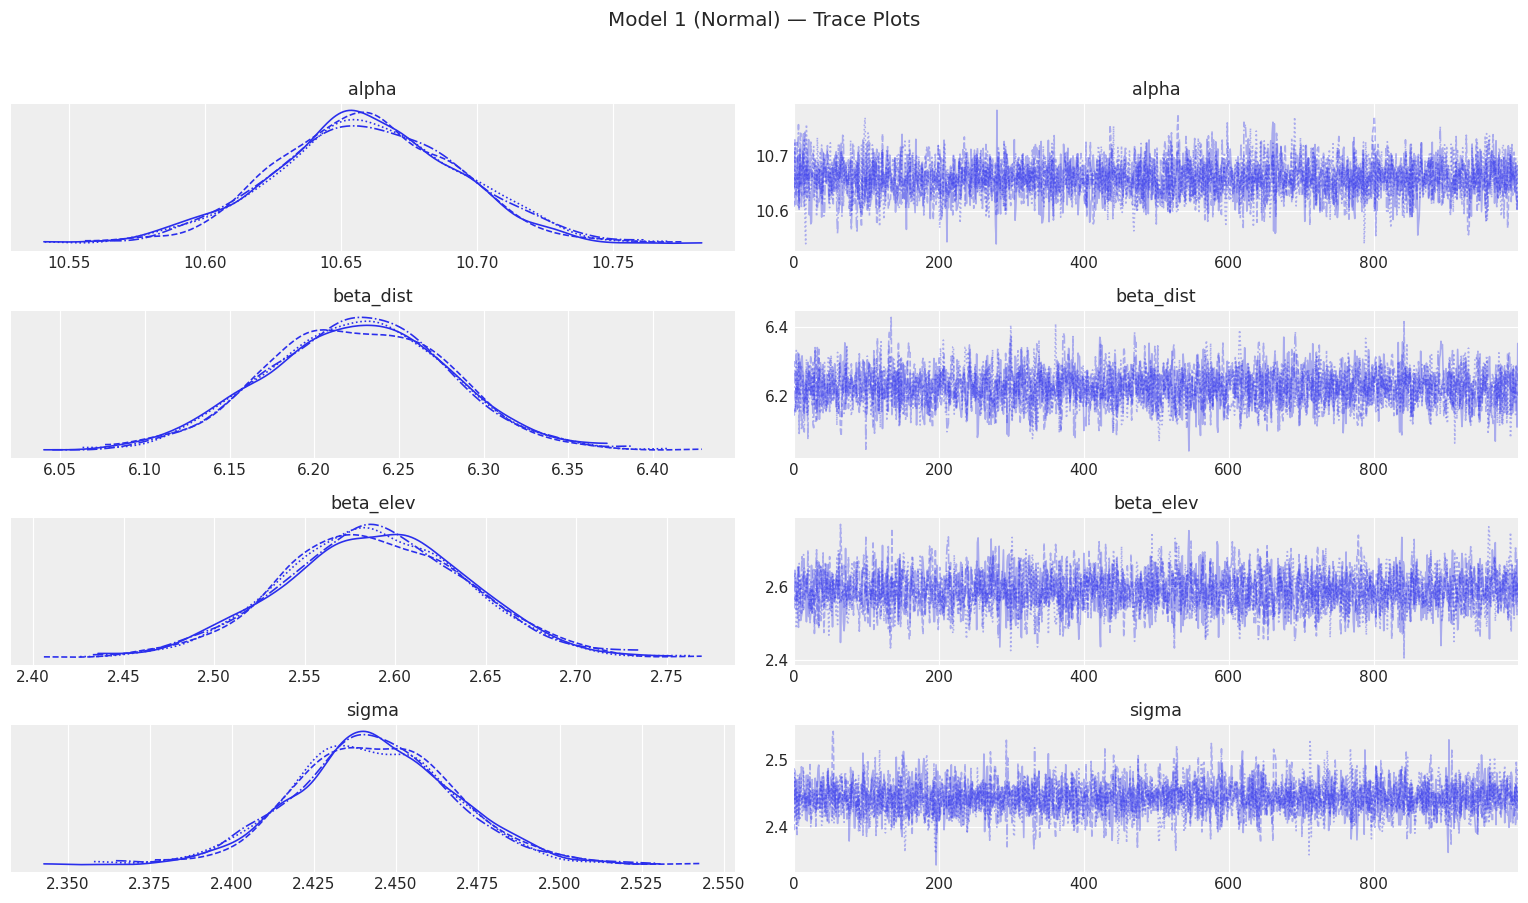


Trace plot assessment:
  → Chains should look like well-mixed 'fuzzy caterpillars'
  → No visible trends, stuck periods, or chain disagreements


In [7]:
# Trace plots
fig = az.plot_trace(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'],
                    figsize=(14, 8), compact=True)
plt.suptitle('Model 1 (Normal) — Trace Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig05_model1_trace.png', bbox_inches='tight')
plt.show()

print("\nTrace plot assessment:")
print("  → Chains should look like well-mixed 'fuzzy caterpillars'")
print("  → No visible trends, stuck periods, or chain disagreements")

### Sampling Assessment

Model 1 is a simple linear regression with conjugate-like structure. We expect:
- No divergences (simple geometry)
- Excellent mixing (R-hat ≈ 1.00, high ESS)
- Well-mixed trace plots

If any issues arise, potential mitigations:
- Increase `iter_sampling` (for low ESS)
- Increase `adapt_delta` (for divergences)
- Check for parameter correlations (pairs plot)

## 3.2 Posterior Predictive Distribution

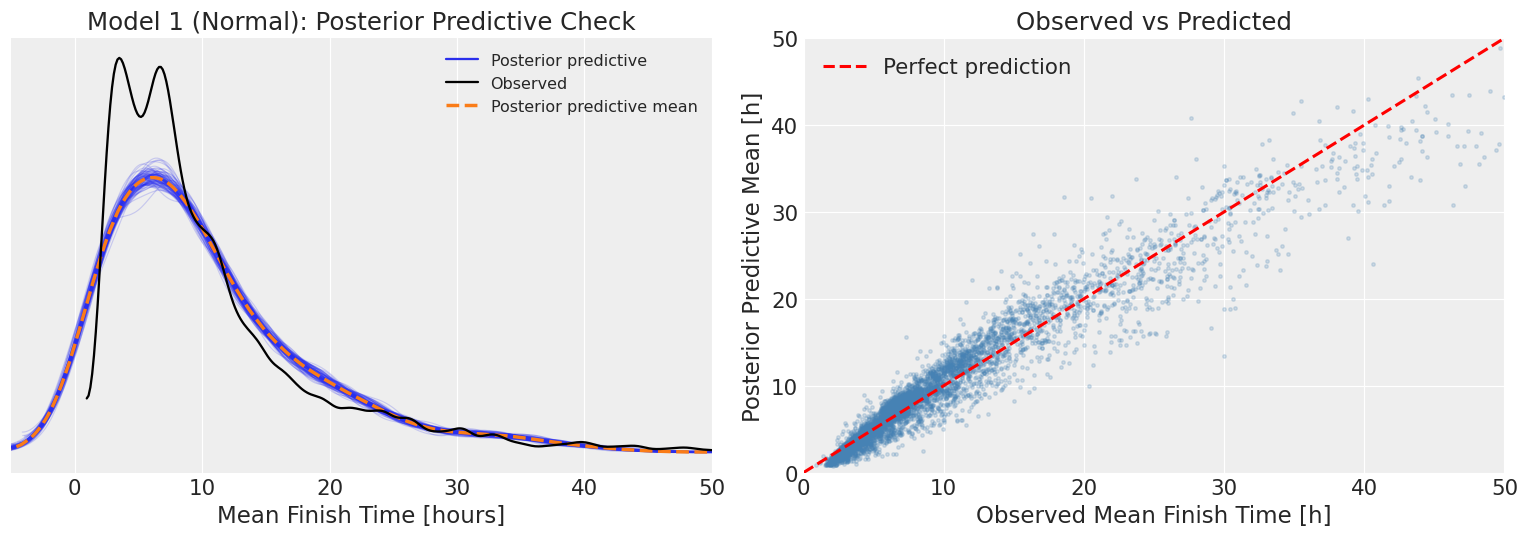

In [8]:
# Posterior predictive check — overall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ArviZ PPC plot
az.plot_ppc(idata1, data_pairs={'y': 'y_rep'}, num_pp_samples=100, ax=axes[0])
axes[0].set_title('Model 1 (Normal): Posterior Predictive Check')
axes[0].set_xlabel('Mean Finish Time [hours]')
axes[0].set_xlim(-5, 50)

# Observed vs predicted scatter
y_obs = df['Mean Finish Time'].values
y_rep_mean = idata1.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs)).mean(axis=0)
axes[1].scatter(y_obs, y_rep_mean, alpha=0.2, s=5, color='steelblue')
axes[1].plot([0, 50], [0, 50], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Observed Mean Finish Time [h]')
axes[1].set_ylabel('Posterior Predictive Mean [h]')
axes[1].set_title('Observed vs Predicted')
axes[1].legend()
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.savefig('fig06_model1_ppc_overall.png', bbox_inches='tight')
plt.show()

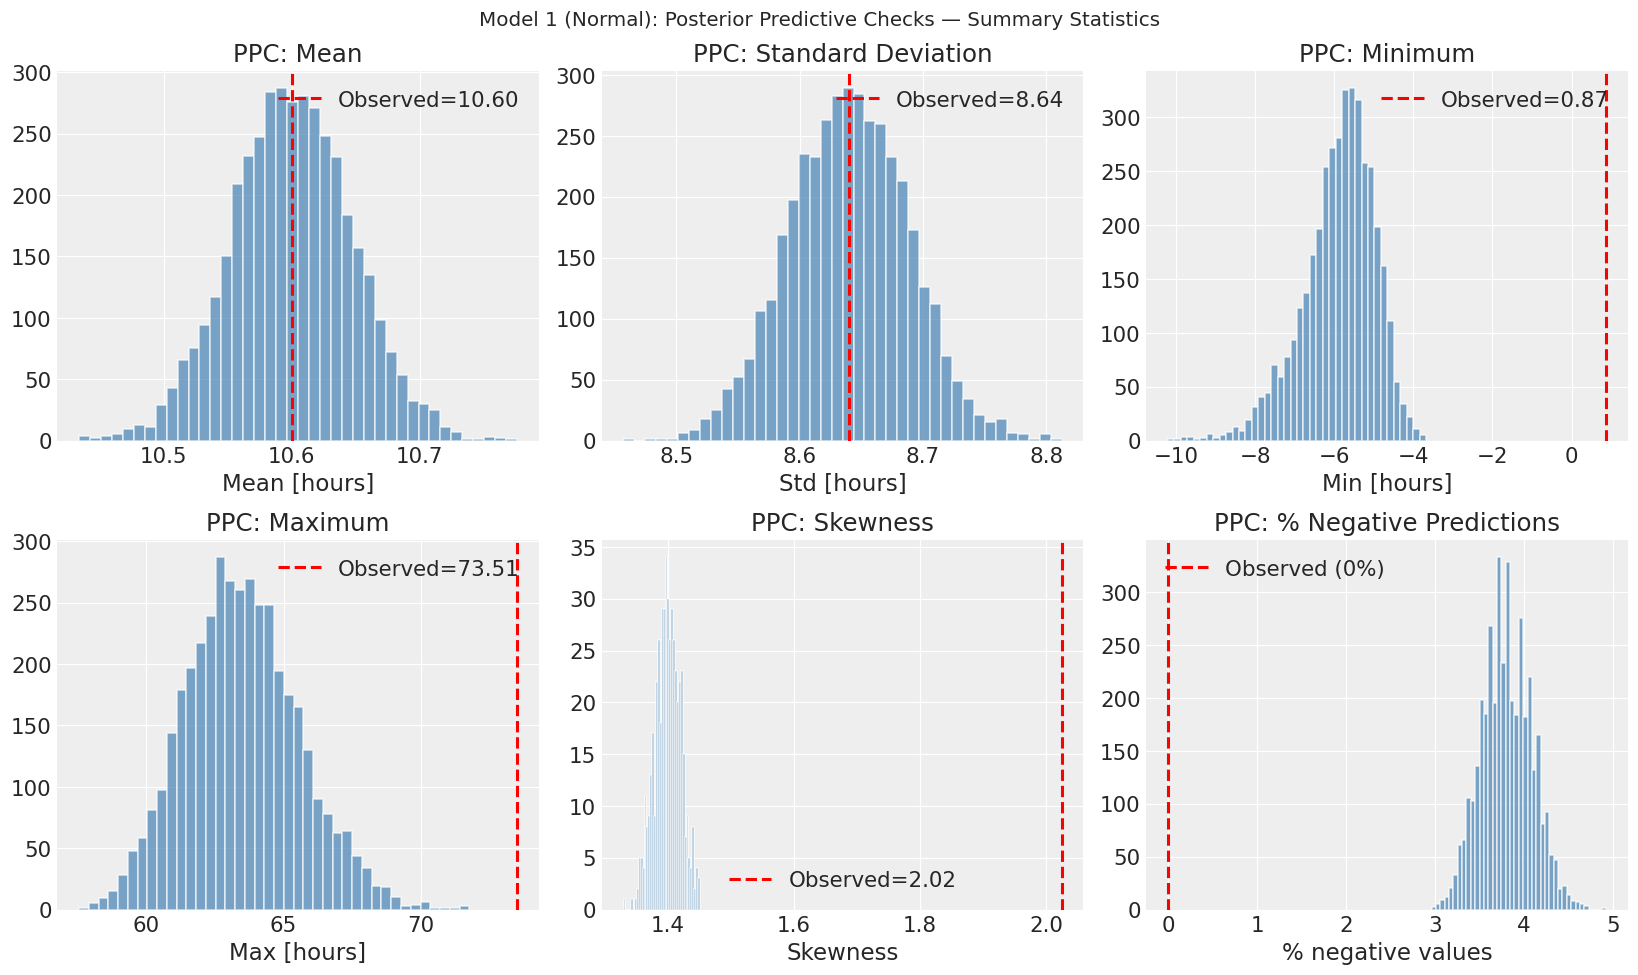

In [9]:
# Posterior predictive — summary statistics comparison
y_rep_samples = idata1.posterior_predictive['y_rep'].values.reshape(-1, len(y_obs))
n_samples = y_rep_samples.shape[0]

# Compute statistics for each posterior predictive sample
pp_means = y_rep_samples.mean(axis=1)
pp_stds = y_rep_samples.std(axis=1)
pp_mins = y_rep_samples.min(axis=1)
pp_maxs = y_rep_samples.max(axis=1)
pp_skew = np.array([stats.skew(y_rep_samples[s]) for s in range(min(500, n_samples))])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Mean
axes[0,0].hist(pp_means, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,0].axvline(y_obs.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.mean():.2f}')
axes[0,0].set_title('PPC: Mean')
axes[0,0].set_xlabel('Mean [hours]')
axes[0,0].legend()

# Std
axes[0,1].hist(pp_stds, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,1].axvline(y_obs.std(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.std():.2f}')
axes[0,1].set_title('PPC: Standard Deviation')
axes[0,1].set_xlabel('Std [hours]')
axes[0,1].legend()

# Min
axes[0,2].hist(pp_mins, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,2].axvline(y_obs.min(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.min():.2f}')
axes[0,2].set_title('PPC: Minimum')
axes[0,2].set_xlabel('Min [hours]')
axes[0,2].legend()

# Max
axes[1,0].hist(pp_maxs, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1,0].axvline(y_obs.max(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.max():.2f}')
axes[1,0].set_title('PPC: Maximum')
axes[1,0].set_xlabel('Max [hours]')
axes[1,0].legend()

# Skewness
axes[1,1].hist(pp_skew, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1,1].axvline(stats.skew(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={stats.skew(y_obs):.2f}')
axes[1,1].set_title('PPC: Skewness')
axes[1,1].set_xlabel('Skewness')
axes[1,1].legend()

# Proportion of negative predictions
pp_neg_pct = (y_rep_samples < 0).mean(axis=1) * 100
axes[1,2].hist(pp_neg_pct, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1,2].axvline(0, color='red', linewidth=2, linestyle='--', label='Observed (0%)')
axes[1,2].set_title('PPC: % Negative Predictions')
axes[1,2].set_xlabel('% negative values')
axes[1,2].legend()

plt.suptitle('Model 1 (Normal): Posterior Predictive Checks — Summary Statistics', fontsize=13)
plt.tight_layout()
plt.savefig('fig07_model1_ppc_stats.png', bbox_inches='tight')
plt.show()

## 3.3 Data Consistency Assessment

We check if the observed data statistics fall within the posterior predictive distribution.

In [10]:
# Quantitative assessment
print("Model 1 (Normal) — Posterior Predictive Consistency Check")
print("=" * 65)

def ppc_pvalue(observed_stat, simulated_stats):
    """Bayesian p-value: proportion of simulated stats >= observed."""
    return np.mean(simulated_stats >= observed_stat)

stats_check = [
    ('Mean', y_obs.mean(), pp_means),
    ('Std Dev', y_obs.std(), pp_stds),
    ('Minimum', y_obs.min(), pp_mins),
    ('Maximum', y_obs.max(), pp_maxs),
    ('Skewness', stats.skew(y_obs), pp_skew),
]

print(f"{'Statistic':<15} {'Observed':<12} {'PP Median':<12} {'PP 95% CI':<25} {'p-value':<10} {'Status'}")
print("-" * 85)
for name, obs_val, pp_vals in stats_check:
    pp_med = np.median(pp_vals)
    pp_lo = np.percentile(pp_vals, 2.5)
    pp_hi = np.percentile(pp_vals, 97.5)
    pval = ppc_pvalue(obs_val, pp_vals)
    in_ci = pp_lo <= obs_val <= pp_hi
    status = '✓ consistent' if in_ci else '✗ INCONSISTENT'
    print(f"{name:<15} {obs_val:<12.3f} {pp_med:<12.3f} [{pp_lo:.2f}, {pp_hi:.2f}]{'':>5} {pval:<10.3f} {status}")

print("\n" + "=" * 65)
print("Interpretation:")
print("  - p-values near 0 or 1 indicate the model fails to capture that statistic")
print("  - p-values near 0.5 indicate good calibration")
print("  - The Normal model may struggle with skewness and extreme values")
print("    due to its symmetric, light-tailed nature")

Model 1 (Normal) — Posterior Predictive Consistency Check
Statistic       Observed     PP Median    PP 95% CI                 p-value    Status
-------------------------------------------------------------------------------------
Mean            10.600       10.600       [10.51, 10.69]      0.499      ✓ consistent
Std Dev         8.640        8.640        [8.54, 8.73]      0.505      ✓ consistent
Minimum         0.873        -5.761       [-7.93, -4.44]      0.000      ✗ INCONSISTENT
Maximum         73.507       63.403       [59.64, 67.85]      0.000      ✗ INCONSISTENT
Skewness        2.025        1.401        [1.36, 1.44]      0.000      ✗ INCONSISTENT

Interpretation:
  - p-values near 0 or 1 indicate the model fails to capture that statistic
  - p-values near 0.5 indicate good calibration
  - The Normal model may struggle with skewness and extreme values
    due to its symmetric, light-tailed nature


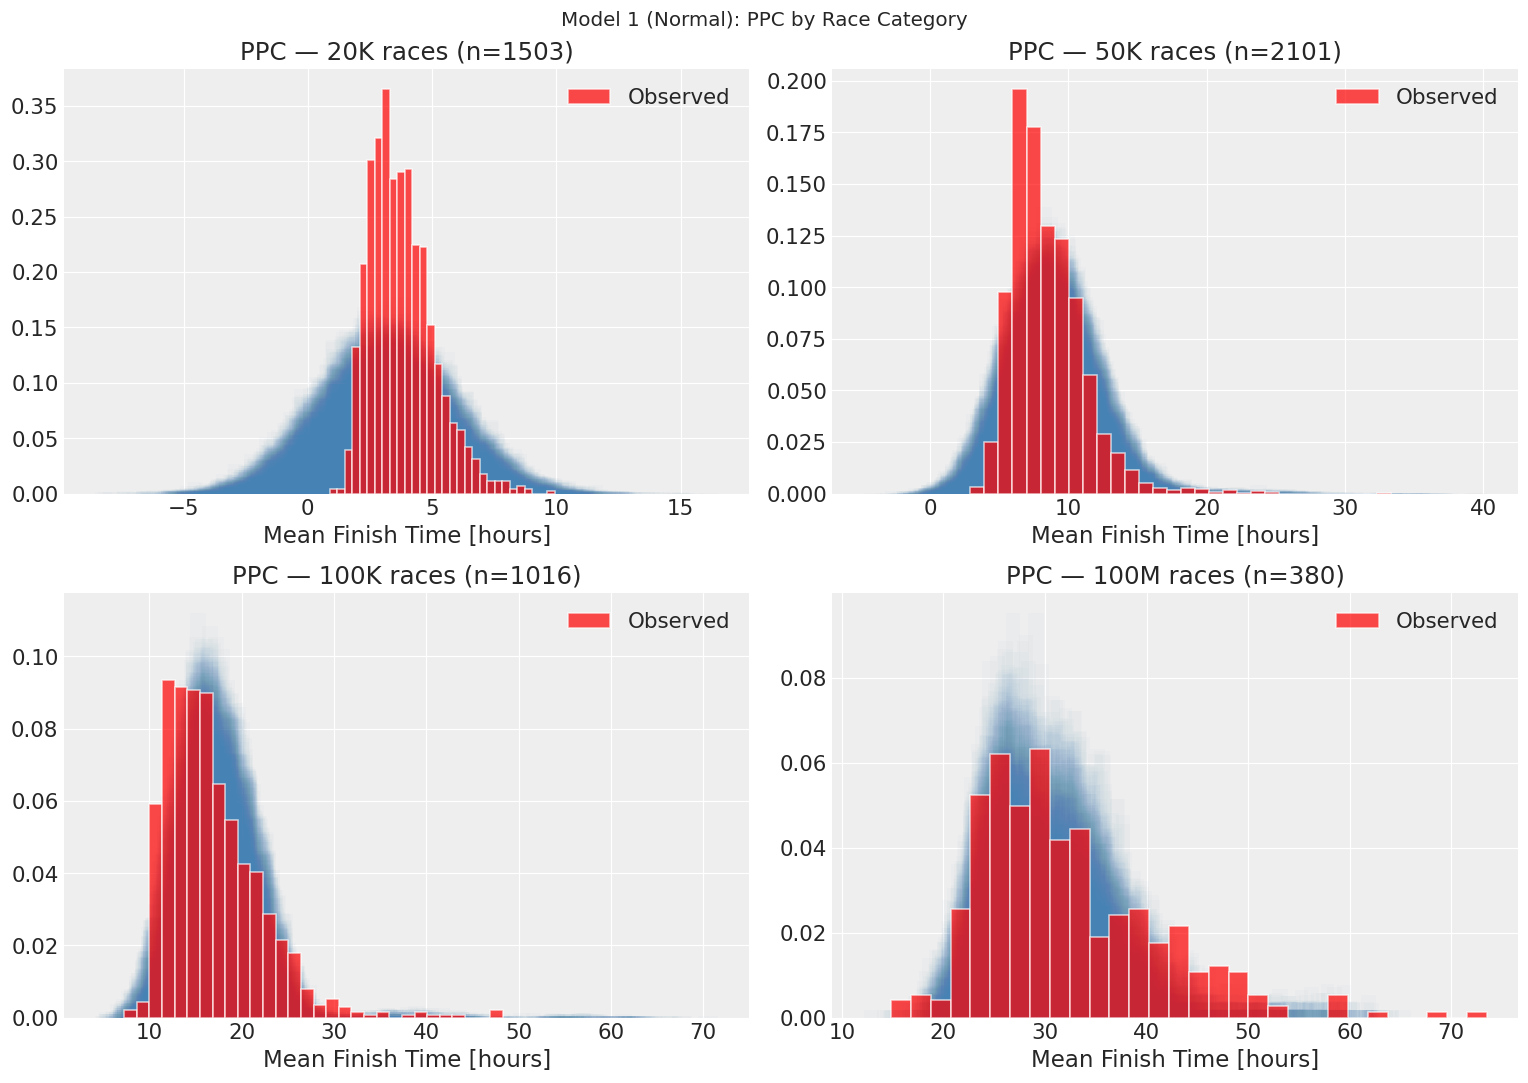

In [11]:
# PPC by race category
categories = ['20K', '50K', '100K', '100M']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cat in enumerate(categories):
    ax = axes[idx // 2, idx % 2]
    mask = df['Race Category'].values == cat
    y_cat = y_obs[mask]
    y_rep_cat = y_rep_samples[:500, mask]  # use subset for speed
    
    # Plot posterior predictive density
    for s in range(min(100, y_rep_cat.shape[0])):
        ax.hist(y_rep_cat[s], bins=30, density=True, alpha=0.02, color='steelblue')
    ax.hist(y_cat, bins=30, density=True, alpha=0.7, color='red', edgecolor='white', label='Observed')
    ax.set_title(f'PPC — {cat} races (n={mask.sum()})')
    ax.set_xlabel('Mean Finish Time [hours]')
    ax.legend()

plt.suptitle('Model 1 (Normal): PPC by Race Category', fontsize=13)
plt.tight_layout()
plt.savefig('fig08_model1_ppc_categories.png', bbox_inches='tight')
plt.show()

## 3.4 Marginal Posterior Distributions

We analyze the posterior marginal distributions of all parameters.

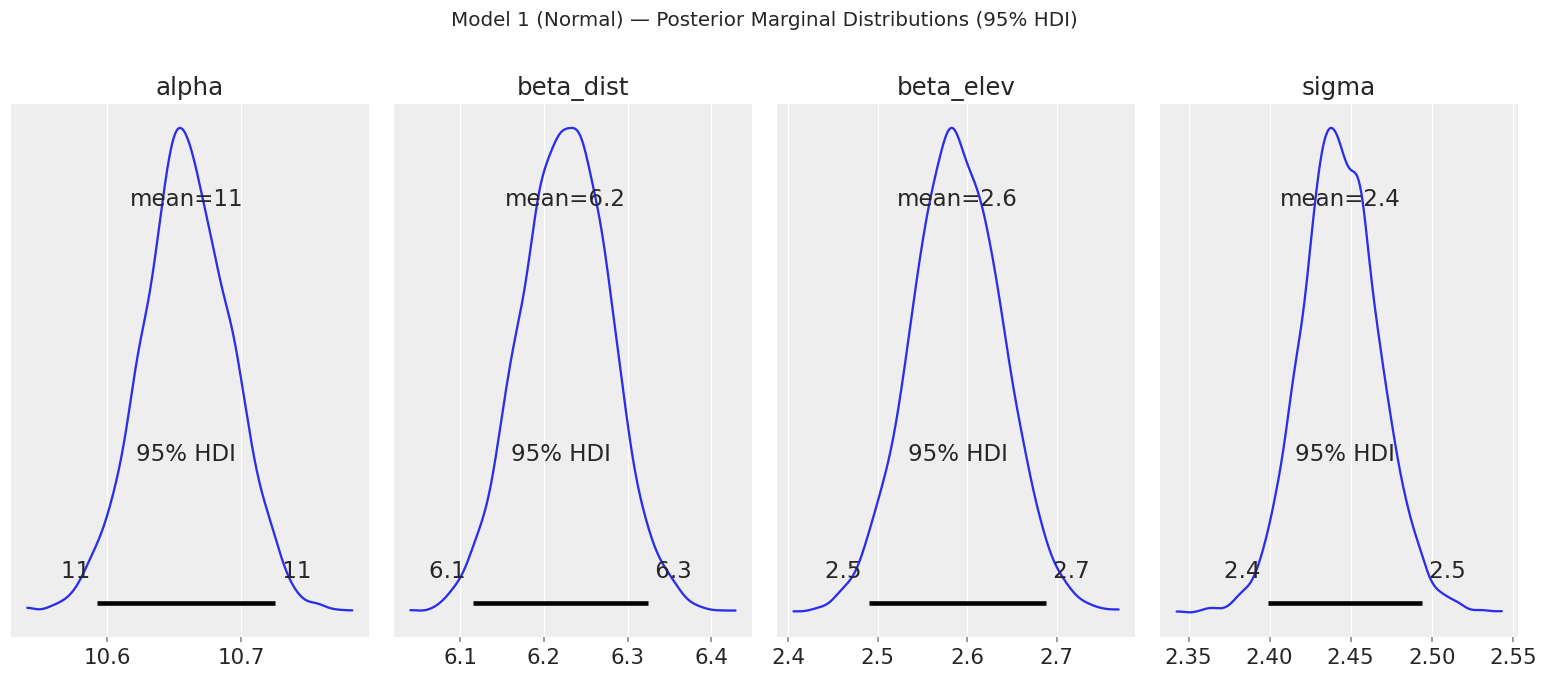

In [12]:
# Posterior marginal distributions
fig = az.plot_posterior(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'],
                        figsize=(14, 6), hdi_prob=0.95)
plt.suptitle('Model 1 (Normal) — Posterior Marginal Distributions (95% HDI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig09_model1_posteriors.png', bbox_inches='tight')
plt.show()

In [13]:
# Detailed parameter analysis
print("Model 1 (Normal) — Parameter Interpretation")
print("=" * 65)

# Extract posterior samples
alpha_post = idata1.posterior['alpha'].values.flatten()
beta_dist_post = idata1.posterior['beta_dist'].values.flatten()
beta_elev_post = idata1.posterior['beta_elev'].values.flatten()
sigma_post = idata1.posterior['sigma'].values.flatten()

dist_mean = df['Distance'].mean()
dist_std = df['Distance'].std()
elev_mean = df['Elevation Gain'].mean()
elev_std = df['Elevation Gain'].std()

print(f"\n--- alpha (intercept) ---")
print(f"  Posterior mean: {alpha_post.mean():.2f} h")
print(f"  95% HDI: [{np.percentile(alpha_post, 2.5):.2f}, {np.percentile(alpha_post, 97.5):.2f}] h")
print(f"  Interpretation: Expected finish time for a race with average distance ({dist_mean:.0f}km)")
print(f"                  and average elevation ({elev_mean:.0f}m)")

print(f"\n--- beta_dist (distance effect) ---")
print(f"  Posterior mean: {beta_dist_post.mean():.2f} h per SD of distance")
print(f"  95% HDI: [{np.percentile(beta_dist_post, 2.5):.2f}, {np.percentile(beta_dist_post, 97.5):.2f}]")
print(f"  In original units: {beta_dist_post.mean()/dist_std*10:.2f} h per 10 km")
print(f"  P(beta_dist > 0): {(beta_dist_post > 0).mean():.4f}")

print(f"\n--- beta_elev (elevation effect) ---")
print(f"  Posterior mean: {beta_elev_post.mean():.2f} h per SD of elevation")
print(f"  95% HDI: [{np.percentile(beta_elev_post, 2.5):.2f}, {np.percentile(beta_elev_post, 97.5):.2f}]")
print(f"  In original units: {beta_elev_post.mean()/elev_std*1000:.2f} h per 1000m elevation")
print(f"  P(beta_elev > 0): {(beta_elev_post > 0).mean():.4f}")

print(f"\n--- sigma (residual SD) ---")
print(f"  Posterior mean: {sigma_post.mean():.2f} h")
print(f"  95% HDI: [{np.percentile(sigma_post, 2.5):.2f}, {np.percentile(sigma_post, 97.5):.2f}]")
print(f"  Interpretation: After accounting for distance and elevation,")
print(f"                  remaining race-to-race variability is ~{sigma_post.mean():.1f}h")

print(f"\n--- Concentration/Diffusion ---")
print(f"  alpha CV:     {alpha_post.std()/abs(alpha_post.mean())*100:.1f}%")
print(f"  beta_dist CV: {beta_dist_post.std()/abs(beta_dist_post.mean())*100:.1f}%")
print(f"  beta_elev CV: {beta_elev_post.std()/abs(beta_elev_post.mean())*100:.1f}%")
print(f"  sigma CV:     {sigma_post.std()/abs(sigma_post.mean())*100:.1f}%")
print(f"  → Low CVs indicate well-identified (concentrated) posteriors.")

Model 1 (Normal) — Parameter Interpretation

--- alpha (intercept) ---
  Posterior mean: 10.66 h
  95% HDI: [10.59, 10.72] h
  Interpretation: Expected finish time for a race with average distance (60km)
                  and average elevation (2532m)

--- beta_dist (distance effect) ---
  Posterior mean: 6.23 h per SD of distance
  95% HDI: [6.12, 6.33]
  In original units: 1.56 h per 10 km
  P(beta_dist > 0): 1.0000

--- beta_elev (elevation effect) ---
  Posterior mean: 2.59 h per SD of elevation
  95% HDI: [2.49, 2.69]
  In original units: 1.35 h per 1000m elevation
  P(beta_elev > 0): 1.0000

--- sigma (residual SD) ---
  Posterior mean: 2.44 h
  95% HDI: [2.40, 2.49]
  Interpretation: After accounting for distance and elevation,
                  remaining race-to-race variability is ~2.4h

--- Concentration/Diffusion ---
  alpha CV:     0.3%
  beta_dist CV: 0.9%
  beta_elev CV: 2.0%
  sigma CV:     1.0%
  → Low CVs indicate well-identified (concentrated) posteriors.


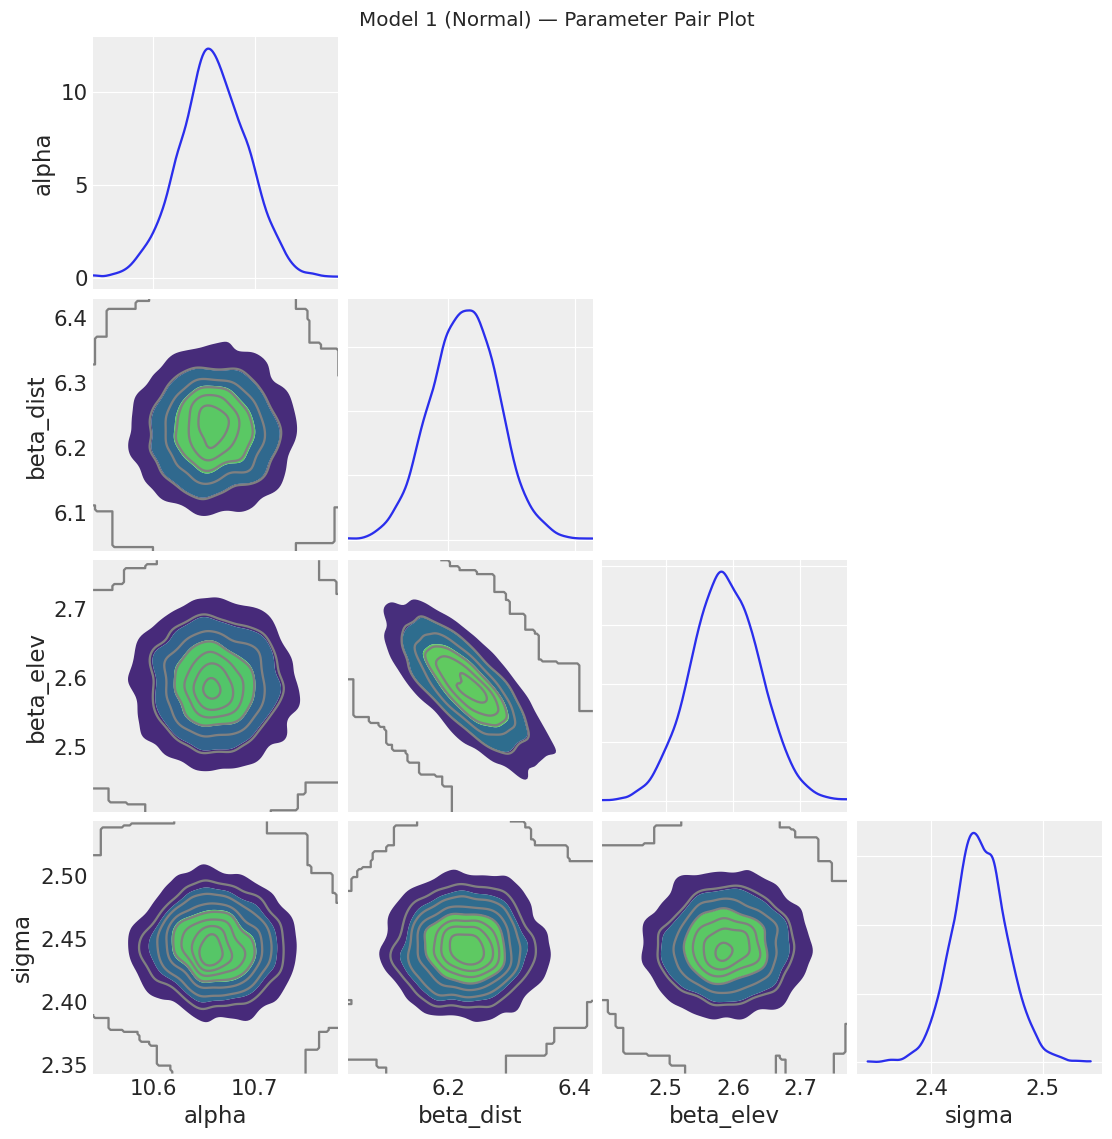


Pair plot assessment:
  → Check for strong correlations between parameters
  → Banana-shaped or multimodal posteriors indicate identification issues
  → Since predictors are standardized, alpha should be nearly independent of betas


In [14]:
# Pair plot — check for parameter correlations
fig = az.plot_pair(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'sigma'],
                   kind='kde', figsize=(10, 10), marginals=True)
plt.suptitle('Model 1 (Normal) — Parameter Pair Plot', fontsize=13, y=1.02)
plt.savefig('fig10_model1_pairs.png', bbox_inches='tight')
plt.show()

print("\nPair plot assessment:")
print("  → Check for strong correlations between parameters")
print("  → Banana-shaped or multimodal posteriors indicate identification issues")
print("  → Since predictors are standardized, alpha should be nearly independent of betas")

## 3.5 Model 1 Summary and Limitations

### Strengths
- Simple, interpretable model
- Fast sampling, no convergence issues expected
- Captures the main linear relationship between distance/elevation and finish time

### Potential Limitations
- Normal likelihood assumes symmetric residuals
- Light tails: outlier races inflate $\sigma$ for all predictions
- May predict negative finish times for short/flat races
- Homoscedasticity assumption may be violated (variance likely increases with predicted time)

These limitations motivate Model 2 (Student-t), which we analyze in the next notebook.